# Sub-nodes sweep: total network samples vs. test 1-R2

Loads results from the four sub-node sweeps:

- `runs_datalimits_msg_nodes5/`  (5 nodes kept)
- `runs_datalimits_msg_nodes10/` (10 nodes kept)
- `runs_datalimits_msg_nodes15/` (15 nodes kept)
- `runs_datalimits_msg_nodes20/` (full 20-node graph)

For `nodes20` only `num_train_samples in [2, 4, ..., 40]` is loaded; for the
other directories every available `num_train_samples` is loaded.

**Plot:** x = total network samples = `num_nodes_keep * num_train_samples`,
y = single-step test `1 - R²`. One curve per `num_nodes_keep`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / 'Hungarianchickenpox' / 'datalimits4dyn_nozscore',
    ]
    for candidate in candidates:
        if (candidate / 'runs_datalimits_msg_nodes5').exists():
            return candidate
    raise FileNotFoundError('Could not locate Hungarianchickenpox/datalimits4dyn_nozscore from the current working directory.')


BASE_DIR = resolve_base_dir()
print('Base dir:', BASE_DIR)

DIR_SPECS = {
    5:  ('runs_datalimits_msg_nodes5',  None),
    10: ('runs_datalimits_msg_nodes10', None),
    15: ('runs_datalimits_msg_nodes15', list(range(2, 54, 3))),
    20: ('runs_datalimits_msg_nodes20', list(range(2, 41, 2))),
}
TARGET_ADJ_TYPE = 'runs3thr0p6'
TARGET_MSG_CONFIG = 'rate_x'
for n, (sub, _) in DIR_SPECS.items():
    p = BASE_DIR / sub
    print(f'  N={n:>2}: {sub} ({"exists" if p.is_dir() else "MISSING"})')
print('Target:', TARGET_ADJ_TYPE, '|', TARGET_MSG_CONFIG)


Base dir: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/datalimits4dyn_nozscore
  N= 5: runs_datalimits_msg_nodes5 (exists)
  N=10: runs_datalimits_msg_nodes10 (exists)
  N=15: runs_datalimits_msg_nodes15 (exists)
  N=20: runs_datalimits_msg_nodes20 (exists)
Target: runs3thr0p6 | rate_x


In [2]:
import re

PATTERN = re.compile(
    r'^run(?P<seed>\d+)_'
    r'(?P<adj>runs\d+thr\d+p\d+)_'
    r'(?P<msg>rate_x)_'
    r'(?P<zscore>nozscore|zscore)_'
    r'(?P<smooth>gaussian|none)_'
    r'n(?P<n>\d+)$'
)

rows = []
for num_nodes, (sub, keep_list) in DIR_SPECS.items():
    runs_dir = BASE_DIR / sub
    if not runs_dir.is_dir():
        print(f'[skip] {runs_dir} does not exist')
        continue
    keep_set = set(keep_list) if keep_list is not None else None
    n_loaded = 0
    for entry in sorted(runs_dir.iterdir()):
        if not entry.is_dir():
            continue
        m = PATTERN.match(entry.name)
        if not m:
            continue
        if m.group('adj') != TARGET_ADJ_TYPE or m.group('msg') != TARGET_MSG_CONFIG:
            continue
        n_train = int(m.group('n'))
        if keep_set is not None and n_train not in keep_set:
            continue
        res_path = entry / 'results.json'
        if not res_path.is_file():
            continue
        with open(res_path) as f:
            res = json.load(f)
        test = res.get('test', {})
        rows.append({
            'run_name': entry.name,
            'num_nodes_keep': num_nodes,
            'seed': int(m.group('seed')),
            'adj_type': m.group('adj'),
            'msg_config': m.group('msg'),
            'zscore': m.group('zscore'),
            'smooth': m.group('smooth'),
            'num_train_samples': n_train,
            'total_samples': num_nodes * n_train,
            'test_r2': float(test.get('r2', np.nan)),
            'test_mse': float(test.get('mse', np.nan)),
            'test_node_r2_mean': float(test.get('node_r2_mean', np.nan)),
        })
        n_loaded += 1
    print(f'  N={num_nodes:>2}: loaded {n_loaded} runs from {sub}')

df = pd.DataFrame(rows)
df['one_minus_r2'] = 1.0 - df['test_r2']
print(f'\nTotal rows: {len(df)}')
if len(df):
    print('num_nodes_keep:', sorted(df.num_nodes_keep.unique()))
    print('adj_types:    ', sorted(df.adj_type.unique()))
    print('msg_configs:  ', sorted(df.msg_config.unique()))
    print('seeds:        ', sorted(df.seed.unique()))
df.head()


  N= 5: loaded 100 runs from runs_datalimits_msg_nodes5
  N=10: loaded 100 runs from runs_datalimits_msg_nodes10
  N=15: loaded 90 runs from runs_datalimits_msg_nodes15
  N=20: loaded 100 runs from runs_datalimits_msg_nodes20

Total rows: 390
num_nodes_keep: [5, 10, 15, 20]
adj_types:     ['runs3thr0p6']
msg_configs:   ['rate_x']
seeds:         [1, 2, 3, 4, 5]


,run_name,num_nodes_keep,seed,adj_type,msg_config,zscore,smooth,num_train_samples,total_samples,test_r2,test_mse,test_node_r2_mean,one_minus_r2
0,run1_runs3thr0p6_rate_x_nozscore_gaussian_n10,5,1,runs3thr0p6,rate_x,nozscore,gaussian,10,50,0.487997,24.750954,0.470475,0.512003
1,run1_runs3thr0p6_rate_x_nozscore_gaussian_n106,5,1,runs3thr0p6,rate_x,nozscore,gaussian,106,530,0.728041,13.146852,0.715404,0.271959
2,run1_runs3thr0p6_rate_x_nozscore_gaussian_n114,5,1,runs3thr0p6,rate_x,nozscore,gaussian,114,570,0.713248,13.861978,0.706688,0.286752
3,run1_runs3thr0p6_rate_x_nozscore_gaussian_n122,5,1,runs3thr0p6,rate_x,nozscore,gaussian,122,610,0.734393,12.839790,0.729565,0.265607
4,run1_runs3thr0p6_rate_x_nozscore_gaussian_n130,5,1,runs3thr0p6,rate_x,nozscore,gaussian,130,650,0.740843,12.528020,0.736111,0.259157


In [3]:
# Aggregate over seeds (and across adj_type / msg_config) for each
# (num_nodes_keep, total_samples) pair. Mean and std on `one_minus_r2`.
agg = (df.groupby(['num_nodes_keep', 'total_samples'])
         .agg(mean_one_minus_r2=('one_minus_r2', 'mean'),
              std_one_minus_r2=('one_minus_r2', 'std'),
              n_runs=('one_minus_r2', 'count'))
         .reset_index()
         .sort_values(['num_nodes_keep', 'total_samples']))
agg.head()

,num_nodes_keep,total_samples,mean_one_minus_r2,std_one_minus_r2,n_runs
0,5,10,1.061326,0.082048,5
1,5,50,0.624987,0.232239,5
2,5,90,0.516611,0.151041,5
3,5,130,0.361980,0.070123,5
4,5,170,0.332567,0.051756,5


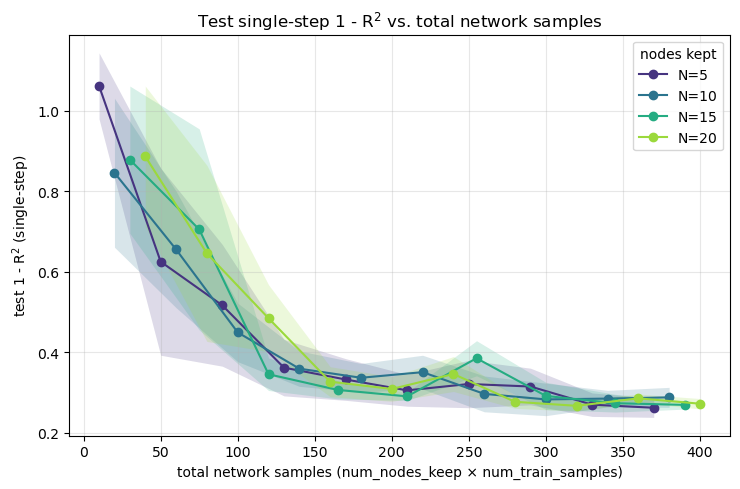

In [4]:
X_MAX = 400  # only plot points with total_samples <= X_MAX

# Single combined plot: x = total network samples, y = test 1 - R^2,
# one curve per num_nodes_keep, averaged across (adj_type, msg_config, seed).
node_counts = sorted(df.num_nodes_keep.unique())
color_map = {n: c for n, c in zip(node_counts, plt.cm.viridis(np.linspace(0.15, 0.85, len(node_counts))))}

fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.0))
for n in node_counts:
    s = agg[agg.num_nodes_keep == n].sort_values('total_samples')
    s = s[s.total_samples <= X_MAX]
    if s.empty:
        continue
    ax.plot(s.total_samples, s.mean_one_minus_r2,
            marker='o', label=f'N={n}', color=color_map[n])
    if (s.n_runs > 1).any():
        ax.fill_between(s.total_samples,
                        s.mean_one_minus_r2 - s.std_one_minus_r2,
                        s.mean_one_minus_r2 + s.std_one_minus_r2,
                        color=color_map[n], alpha=0.18, linewidth=0)

ax.set_xlabel('total network samples (num_nodes_keep × num_train_samples)')
ax.set_ylabel('test 1 - R$^2$ (single-step)')
ax.set_title('Test single-step 1 - R$^2$ vs. total network samples')
ax.grid(alpha=0.3)
ax.legend(title='nodes kept', loc='best')
fig.tight_layout()
# fig.savefig(os.path.join(BASE_DIR, 'subnodes_total_samples_vs_test_one_minus_r2.png'),
            # dpi=150, bbox_inches='tight')
plt.show()

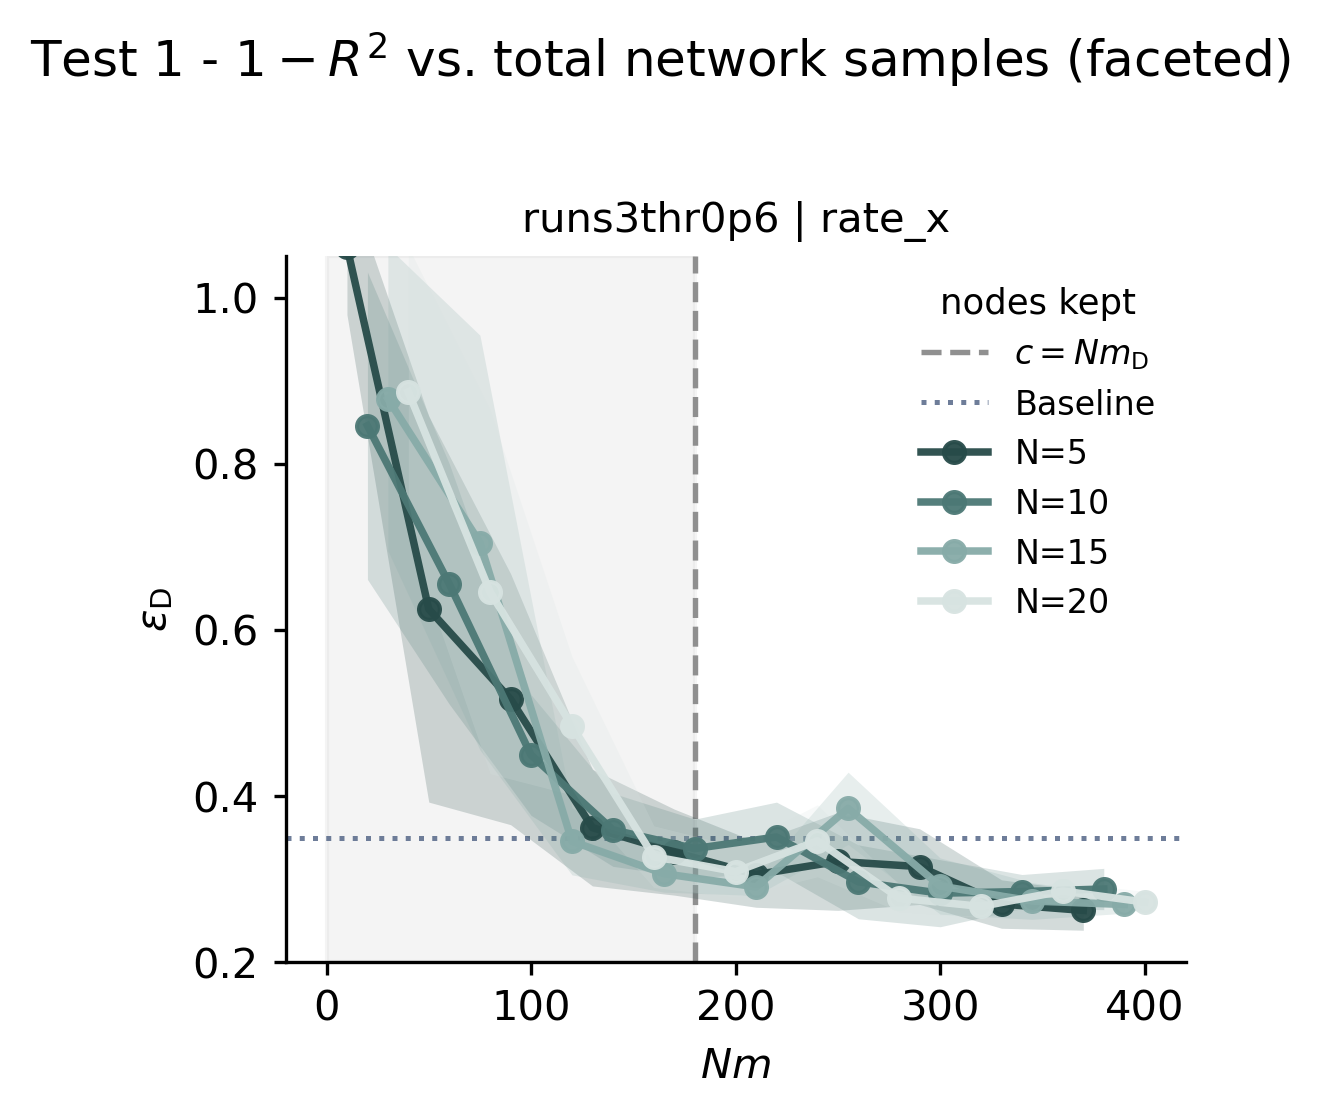

In [5]:
from matplotlib.colors import LinearSegmentedColormap, to_hex
import numpy as np
import matplotlib.pyplot as plt

agg_facet = (
    df.groupby(['adj_type', 'msg_config', 'num_nodes_keep', 'total_samples'])
      .agg(mean_one_minus_r2=('one_minus_r2', 'mean'),
           std_one_minus_r2=('one_minus_r2', 'std'),
           n_runs=('one_minus_r2', 'count'))
      .reset_index()
)

adj_types = [TARGET_ADJ_TYPE]
msg_configs = [TARGET_MSG_CONFIG]

# node_cmap = LinearSegmentedColormap.from_list('fig5_nodes', ['#6F8F8D', '#4F6B69', '#A8BDBC'])
node_cmap = LinearSegmentedColormap.from_list('fig5_nodes', ['#274B49', '#5F8F8B', '#D7E3E1'])
color_map = {n: to_hex(node_cmap(i / (len(node_counts) - 1))) if len(node_counts) > 1 else '#6F8F8D'
             for i, n in enumerate(node_counts)}

fig, axes = plt.subplots(len(msg_configs), len(adj_types),
                         figsize=(3.8 * len(adj_types), 3.6 * len(msg_configs)),
                         sharex=True, sharey=True, squeeze=False, dpi=300)

for i, msg in enumerate(msg_configs):
    for j, adj in enumerate(adj_types):
        ax = axes[i][j]
        sub = agg_facet[(agg_facet.adj_type == adj) & (agg_facet.msg_config == msg)]

        x_ref = 180.0
        ax.axvspan(0, x_ref, color='#D9D9D9', alpha=0.28, zorder=0)
        ax.axvline(x_ref, linestyle='--', color='#8A8A8A', linewidth=1.3, alpha=0.95,
                   label=r'$c = N m_\mathrm{D}$', zorder=1)

        if i == 0:
            y = 0.35
            ax.axhline(y, linestyle=':', color='#5E6F8E', linewidth=1.2, alpha=0.9,
                       label='Baseline', zorder=1)
            ax.set_ylim(0.2, 1.05)
            # ax.set_xlim(left = 0.0)
        elif i == 1:
            y = 0.3
            ax.axhline(y, linestyle=':', color='#5E6F8E', linewidth=1.2, alpha=0.9,
                       label='Baseline', zorder=1)
            ax.set_ylim(0.2, 1.2)
            # ax.set_xlim(left = 0.0)

        for n in node_counts:
            s = sub[sub.num_nodes_keep == n].sort_values('total_samples')
            s = s[s.total_samples <= X_MAX]
            if s.empty:
                continue
            c = color_map[n]
            ax.plot(s.total_samples, s.mean_one_minus_r2, marker='o', ms=5, lw=1.8,
                    color=c, alpha=0.95, label=f'N={n}', zorder=3)
            if (s.n_runs > 1).any():
                ax.fill_between(s.total_samples,
                                s.mean_one_minus_r2 - s.std_one_minus_r2,
                                s.mean_one_minus_r2 + s.std_one_minus_r2,
                                color=c, alpha=0.20, linewidth=0, zorder=2)

        ax.set_title(f'{TARGET_ADJ_TYPE} | {TARGET_MSG_CONFIG}', fontsize=10, pad=6)
        if i == len(msg_configs) - 1:
            ax.set_xlabel(r'$Nm$')
        if j == 0:
            ax.set_ylabel(r'$\epsilon_\mathrm{D}$')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.tick_params(direction='out', length=3.0, width=0.8)
        ax.set_axisbelow(True)

axes[0][-1].legend(title='nodes kept', loc='best', fontsize=8, frameon=False, title_fontsize=8.5)
fig.suptitle(r'Test 1 - $1 - R^2$ vs. total network samples (faceted)', y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(BASE_DIR, 'subnodes_total_samples_vs_test_one_minus_r2_faceted_v1.pdf'),
#             dpi=150, bbox_inches='tight')
plt.show()

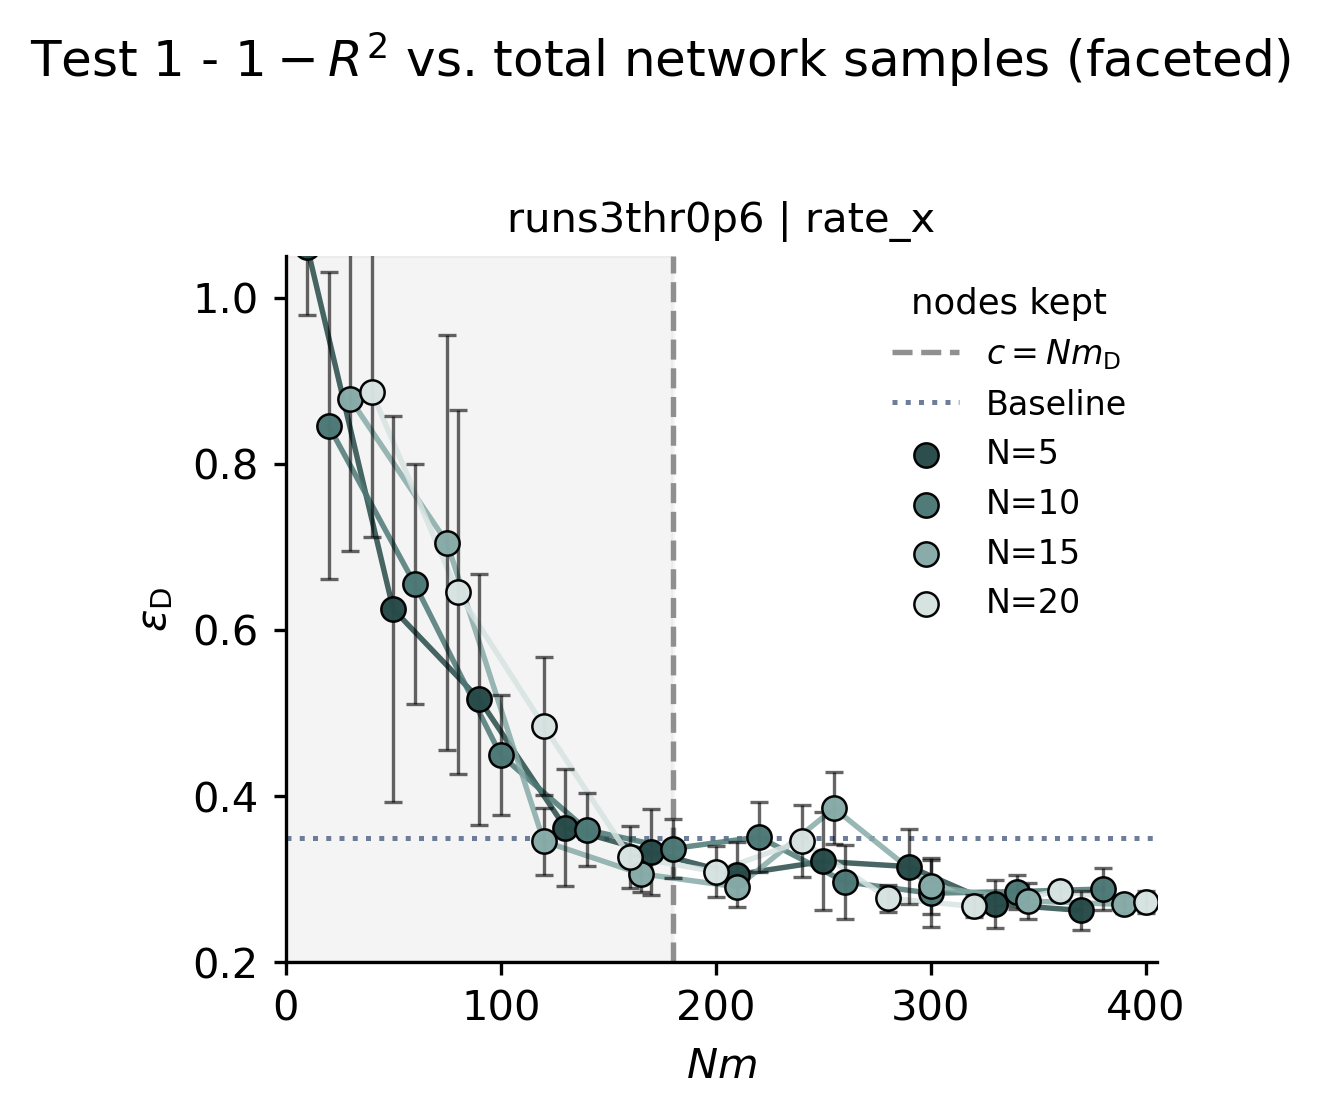

In [6]:
from matplotlib.colors import LinearSegmentedColormap, to_hex
import numpy as np
import matplotlib.pyplot as plt

agg_facet = (
    df.groupby(['adj_type', 'msg_config', 'num_nodes_keep', 'total_samples'])
      .agg(mean_one_minus_r2=('one_minus_r2', 'mean'),
           std_one_minus_r2=('one_minus_r2', 'std'),
           n_runs=('one_minus_r2', 'count'))
      .reset_index()
)

adj_types = [TARGET_ADJ_TYPE]
msg_configs = [TARGET_MSG_CONFIG]

# node_cmap = LinearSegmentedColormap.from_list('fig5_nodes', ['#6F8F8D', '#4F6B69', '#A8BDBC'])
node_cmap = LinearSegmentedColormap.from_list('fig5_nodes', ['#274B49', '#5F8F8B', '#D7E3E1'])
color_map = {n: to_hex(node_cmap(i / (len(node_counts) - 1))) if len(node_counts) > 1 else '#6F8F8D'
             for i, n in enumerate(node_counts)}

fig, axes = plt.subplots(len(msg_configs), len(adj_types),
                         figsize=(3.8 * len(adj_types), 3.6 * len(msg_configs)),
                         sharex=True, sharey=True, squeeze=False, dpi=300)

for i, msg in enumerate(msg_configs):
    for j, adj in enumerate(adj_types):
        ax = axes[i][j]
        sub = agg_facet[(agg_facet.adj_type == adj) & (agg_facet.msg_config == msg)]

        x_ref = 180.0
        ax.axvspan(0, x_ref, color='#D9D9D9', alpha=0.28, zorder=0)
        ax.axvline(x_ref, linestyle='--', color='#8A8A8A', linewidth=1.3, alpha=0.95,
                   label=r'$c = N m_\mathrm{D}$', zorder=1)

        if i == 0:
            ax.axhline(0.35, linestyle=':', color='#5E6F8E', linewidth=1.2, alpha=0.9,
                       label='Baseline', zorder=1)
            ax.set_ylim(0.2, 1.05)
            ax.set_xlim(0.0, 405)
        elif i == 1:
            ax.axhline(0.3, linestyle=':', color='#5E6F8E', linewidth=1.2, alpha=0.9,
                       label='Baseline', zorder=1)
            ax.set_ylim(0.2, 1.2)
            ax.set_xlim(0.0, 405)
        

        for n in node_counts:
            s = sub[sub.num_nodes_keep == n].sort_values('total_samples')
            s = s[s.total_samples <= X_MAX]
            if s.empty:
                continue

            x = s.total_samples.to_numpy(dtype=float)
            y = s.mean_one_minus_r2.to_numpy(dtype=float)
            yerr = s.std_one_minus_r2.fillna(0).to_numpy(dtype=float)
            c = color_map[n]

            ax.plot(x, y, color=c, lw=1.3, alpha=0.85, zorder=2)
            ax.errorbar(x, y, yerr=yerr, fmt='none', ecolor='black', elinewidth=0.8,
                        capsize=2.2, capthick=0.8, alpha=0.6, zorder=3)
            ax.scatter(x, y, s=34, facecolor=c, edgecolor='black', linewidth=0.6,
                       alpha=0.98, label=f'N={n}', zorder=4)

        ax.set_title(f'{TARGET_ADJ_TYPE} | {TARGET_MSG_CONFIG}', fontsize=10, pad=6)
        if i == len(msg_configs) - 1:
            ax.set_xlabel(r'$Nm$')
        if j == 0:
            ax.set_ylabel(r'$\epsilon_\mathrm{D}$')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.tick_params(direction='out', length=3.0, width=0.8)
        ax.set_axisbelow(True)

axes[0][-1].legend(title='nodes kept', loc='best', fontsize=8, frameon=False, title_fontsize=8.5)
fig.suptitle(r'Test 1 - $1 - R^2$ vs. total network samples (faceted)', y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(BASE_DIR, 'subnodes_total_samples_vs_test_one_minus_r2_faceted_v3.pdf'),
#             dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save aggregated tables.
out_csv = BASE_DIR / 'subnodes_total_samples_summary.csv'
agg.to_csv(out_csv, index=False)
print('Wrote', out_csv)

out_csv_facet = BASE_DIR / 'subnodes_total_samples_summary_faceted.csv'
agg_facet.to_csv(out_csv_facet, index=False)
print('Wrote', out_csv_facet)
agg

Wrote /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/datalimits4dyn_nozscore/subnodes_total_samples_summary.csv
Wrote /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/datalimits4dyn_nozscore/subnodes_total_samples_summary_faceted.csv


,num_nodes_keep,total_samples,mean_one_minus_r2,std_one_minus_r2,n_runs
0,5,10,1.061326,0.082048,5
1,5,50,0.624987,0.232239,5
2,5,90,0.516611,0.151041,5
3,5,130,0.361980,0.070123,5
4,5,170,0.332567,0.051756,5
...,...,...,...,...,...
73,20,640,0.247751,0.005929,5
74,20,680,0.251830,0.009724,5
75,20,720,0.244505,0.006652,5
76,20,760,0.240174,0.009906,5
